# Badanie Efektywności Reprezentacji Ortogonalnej Sygnałów 1D

Autorzy:
- Grzegorz Cyba, 274859
- Jan Galewicz 272587

---

## 1. Wstęp



wybrany temat

co chcemy zrobić aka założenia

krótki opis fouriera

zastosowania - do czego się używa

wszystko krótko bo dalej będzie rozwinięte

---

## 2. Generator danych

W celu przeprowadzenia kompleksowej weryfikacji efektywności algorytmu kompresji widmowej opartego na transformacie Fouriera, niezbędne było przygotowanie zróżnicowanego materiału badawczego. Zaimplementowane środowisko pozwala na generowanie trzech klas sygnałów o odmiennych właściwościach w domenie czasu i częstotliwości. Pozwala to na rygorystyczne przetestowanie mechanizmu progowania współczynników pod kątem dokładności rekonstrukcji, zachowania energii oraz zmian entropii sygnału.

### 2.1. Budowa zbioru danych i symulacja zaszumienia pomiarowego

Masowa synteza oraz agregacja struktur sygnałowych realizowana jest przez klasę zarządczą *DatasetCreator*. Narzędzie to automatyzuje proces budowy zbalansowanego datasetu testowego w dyskretnej dziedzinie czasu dla następujących parametrów:
- $t_0 = 0\text{ s}$ — czas początkowy przebiegu,
- $t_{end} = 500\text{ s}$ — czas końcowy przebiegu,
- $dt = 0.1\text{ s}$ — krok czasowy (co daje wektor o długości 5000 próbek),
- $u(t) \in [1, 10]$ — zakres dopuszczalnych wartości (amplitud).

**Powtarzalność i determinizm widma:**

W celu zapewnienia pełnej replikowalności eksperymentów, klasa wykorzystuje obiektowy generator liczb pseudolosowych `np.random.default_rng(seed)`. Przekazywanie tej samej instancji stanu losowego (`rng`) do klas sygnałowych gwarantuje, że przy identycznym ziarnie (seed) wygenerowane trajektorie czasowe oraz ich struktura spektralna (układ harmonicznych w widmie) będą identyczne przy każdym uruchomieniu.

**Separacja danych czystych i zaszumionych:**

Architektura generatora wymusza ścisły podział na fazę syntezy oraz fazę eksperymentu szumowego:
1. **Generowanie bazy** (`create_dataset`): Tworzy i zapisuje w instancji (`self.dataset`) wyłącznie idealnie czyste, referencyjne trajektorie dla każdej z trzech klas sygnałów.
2. **Generowanie zakłóceń** (`create_noisy_dataset_copy`): Tworzy głęboką kopię (`deepcopy`) czystego zbioru bazowego i nakłada na nią szum Gaussowski o intensywności zdefiniowanej przez parametr `noise_level` ($\sigma$). Pozwala to na rygorystyczne badanie wpływu kompresji Fouriera na ten sam sygnał przy różnych poziomach zakłóceń, bez niszczenia danych źródłowych.

Proces zaszumiania kopii realizowany jest zgodnie z zależnością:

$$y_{noisy} = y_{clean} + N(0, \sigma)$$

Aby wartości sygnału po zaszumieniu nie przekroczyły barier fizycznych, końcowy wektor poddawany jest operacji saturacji do przedziału $[u_{min}, u_{max}]$ za pomocą funkcji `np.clip`. Wygenerowane pakiety danych (wektory $t$ oraz $y$) są ostatecznie kapsułkowane w ustrukturyzowanych obiektach klasy `SignalData` i mapowane w zbiorczym słowniku pod kluczami *aprbs*, *multisine* oraz *noise*.

### 2.2 Klasy sygnałów

Każda z zaimplementowanych klas sygnału reprezentuje inny typ struktury spektralnej, co pozwala na ocenę uniwersalności projektowanego kodeka.


#### 2.2.1. Sygnał APRBS (Amplitude Pseudo-Random Binary Sequence)


Sygnał ten charakteryzuje się gwałtownymi, dyskretnymi zmianami amplitudy (skokami napięcia) utrzymywanymi przez losowy czas. Dla każdego pojedynczego przebiegu parametry czasowe są losowane stochastycznie z następujących zakresów:
- $h_{min} \in [50; 150]$ — zakres, z którego losowany jest minimalny czas trwania pojedynczego kroku,
- $h_{add} \in [100; 300]$ — przedział definiujący dodatkowy czas, który po zsumowaniu z $h_{min}$ określa maksymalny czas trwania kroku ($h_{max}$).

Znaczenie w analizie kompresji: Z punktu widzenia analizy Fouriera, ostre zbocza i nieskończony gradient zmian w dziedzinie czasu generują ciągłe, bardzo bogate spektrum częstotliwościowe o wolno wygasających harmonicznych. Jest to najtrudniejszy test dla algorytmu kompresji widmowej. Wycięcie wysokich częstotliwości (współczynników FFT) prowadzi do utraty ostrości krawędzi i generuje charakterystyczne oscylacje wokół punktów skoku po wykonaniu odwrotnej transformaty (tzw. efekt Gibbsa). Pozwala to zbadać, jak mocno ucinanie pasma zniekształca skokowe sygnały szybkozmienne.

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

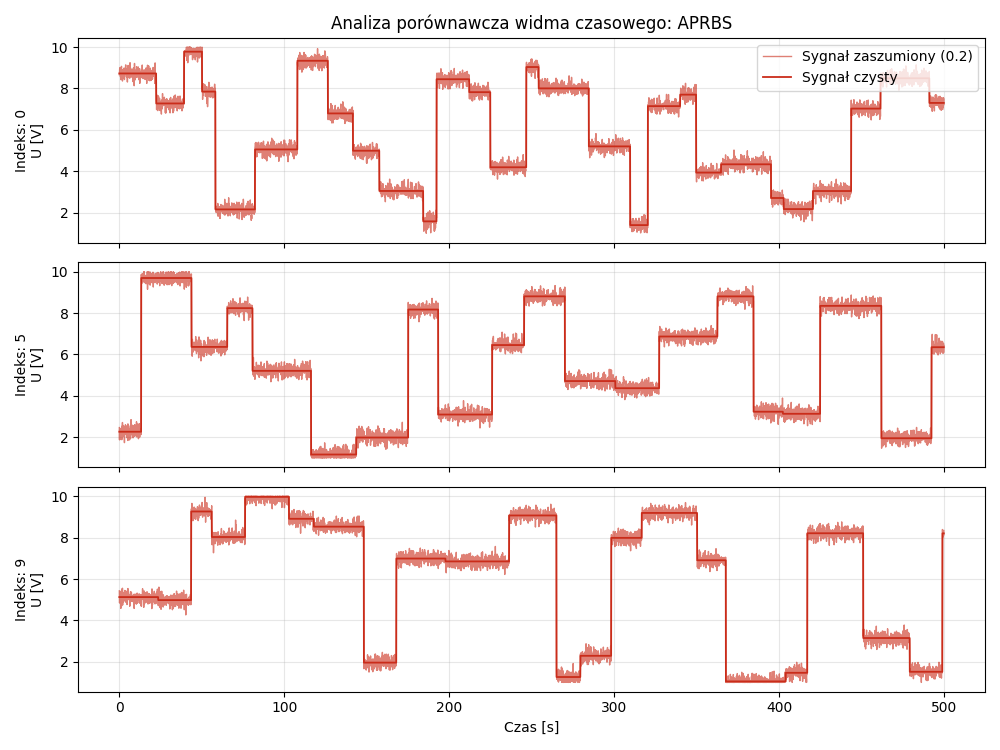

In [5]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=0, n_noise=0)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9], signals_noisy=dataset_noisy['aprbs'], noise_level=creator.noise_level)


#### 2.2.2. Sygnał Multisine (Wieloczęstotliwościowy)

Sygnał ten stanowi deterministyczną sumę składowych harmonicznych (sinusoid) o losowych fazach i częstotliwościach. Dla każdego przebiegu parametry konfiguracyjne losowane są z przedziałów:
- $n_f \in [5; 15]$ — zakres, z którego losowana jest liczba składowych sinusoidalnych,
- $f_{max} \in [0.005; 0.02]\text{ Hz}$ — zakres, z którego losowana jest maksymalna dopuszczalna częstotliwość pojedynczej sinusoidy.

Znaczenie w analizie kompresji: W dziedzinie częstotliwości sygnał ten charakteryzuje się ściśle dyskretnym spektrum prążkowym. Cała energia sygnału skupiona jest w dokładnie $n_f$ punktach widma, podczas gdy pozostała część pasma przyjmuje wartości zerowe. Dla kodeka fourierowskiego jest to sygnał idealny. Algorytm progowania powinien bezbłędnie wyizolować i zachować wyłącznie dominujące prążki częstotliwościowe, co pozwala na uzyskanie minimalnego błędu rekonstrukcji (MSE) i stabilnej entropii widmowej nawet przy bardzo niskim procencie zachowanych danych.

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

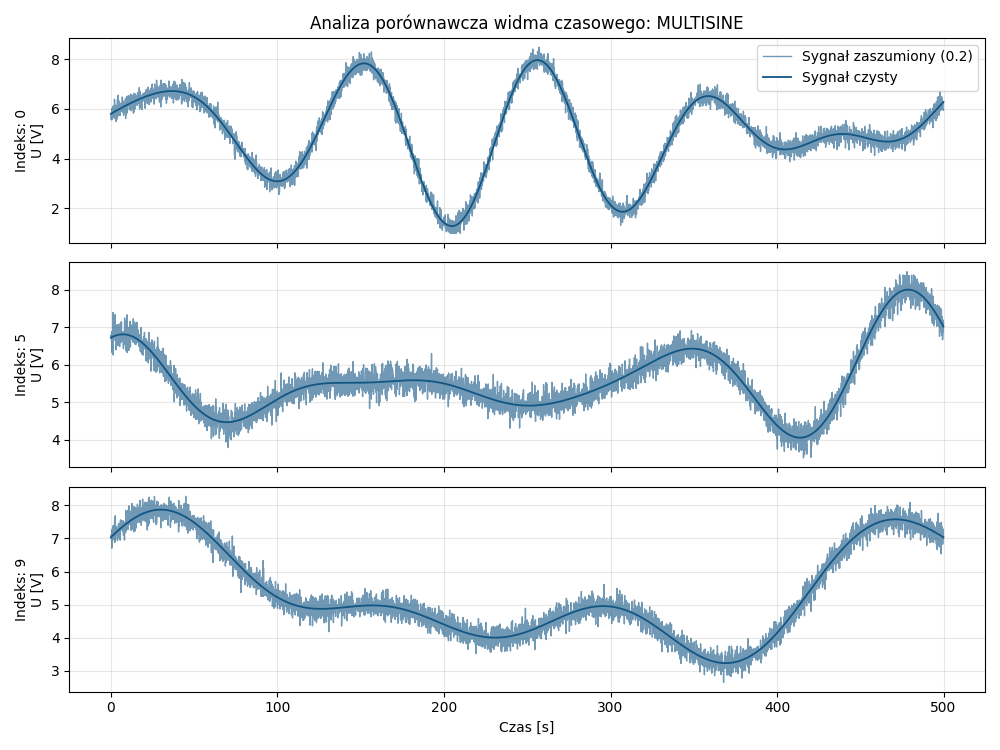

In [4]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=10, n_noise=0)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9], signals_noisy=dataset_noisy['multisine'], noise_level=creator.noise_level)

#### 2.2.3. Przefiltrowany szum dolnoprzepustowy (Filtered Noise)

Sygnał reprezentujący przebieg chaotyczny o kontrolowanym paśmie. Powstaje poprzez generację stochastycznego szumu białego o rozkładzie normalnym, który następnie poddawany jest cyfrowej filtracji dolnoprzepustowej pierwszego rzędu. Częstotliwość odcięcia filtra jest parametrem losowym:
- $cutoff \in [0.001; 0.01]\text{ Hz}$ — zakres losowania częstotliwości odcięcia.

Znaczenie w analizie kompresji: W dziedzinie częstotliwości sygnał ten posiada gęste, ciągłe pasmo szumowe ograniczone od góry filtrem wygładzającym. Brak pojedynczych, dominujących częstotliwości sprawia, że energia jest rozproszona. Pozwala to na zbadanie, jak algorytm kompresji radzi sobie z sygnałami stochastycznymi, gdzie ucinanie współczynników przekłada się bezpośrednio na liniową utratę losowej energii tła, co stanowi kluczowy punkt weryfikacji zmian entropii widmowej oraz dokładności odwzorowania szumów procesowych.

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]

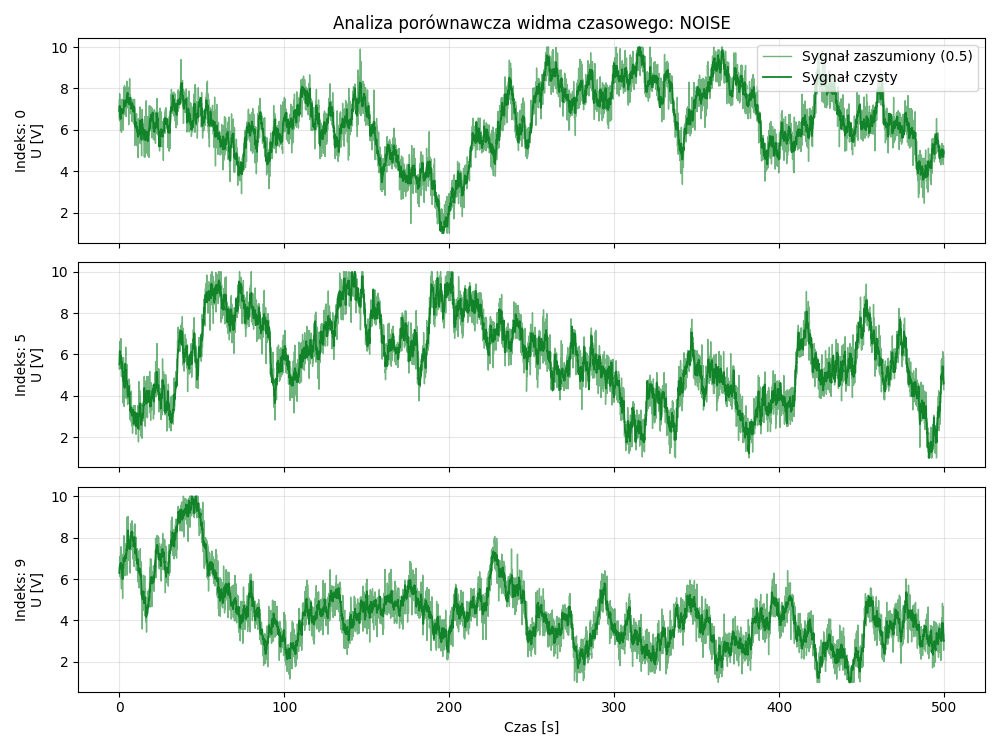

In [3]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.5, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=0, n_noise=10)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9], signals_noisy=dataset_noisy['noise'], noise_level=creator.noise_level)

---

## 3. Fourier



podstawy teoretyczne (DFT)
- prosty
- odwrotny

opis kodu w markdown

kod do uruchomienia
- wykresy jak działa ucinanie (kompresja)
- mse
- przykładowe porównanie numpy vs własne

---

## 4. Strategie kompresji

W tej sekcji zajmiemy się kompresją sygnału w dziedzinie częstotliwości. Cała sztuka polega na tym, żeby wyrzucić (wyzerować) te składowe widma, które niewiele wnoszą, i zostawić tylko te najważniejsze. Dzięki temu wektor częstotliwości staje się rzadki (ma dużo zer), co pozwala mocno "odchudzić" dane, zachowując kluczowe cechy sygnału.

Do wyznaczenia optymalnego punktu odcięcia współczynników przetestujemy dwa różne podejścia adaptacyjne:

1. **Analiza energii (Kryterium Energetyczne):** Podejście szybkie, działające w dziedzinie częstotliwości. Sortujemy prążki od najsilniejszego i na podstawie twierdzenia Parsevala zostawiamy tylko tyle współczynników, ile potrzeba, by zachować np. 99% całkowitej energii sygnału.
2. **Analiza dokładności (Kryterium Fidelity):** Podejście dokładniejsze, działające w dziedzinie czasu. Uruchamiamy szybki algorytm bisekcji (wyszukiwania binarnego), który krok po kroku sprawdza rzeczywisty błąd rekonstrukcji sygnału (MSE lub błąd maksymalny) i szuka minimalnego zestawu prążków, przy którym błąd nie przekracza zadanej tolerancji.

Zanim jednak przejdziemy do samych algorytmów, musimy zdefiniować matematyczne narzędzia, którymi będziemy mierzyli jakość i błędy rekonstrukcji sygnału po jego odtworzeniu.

### 4.1. Metryki oceny jakości rekonstrukcji



Do oceny stopnia zniekształcenia sygnału po kompresji zaimplementowano klasę `SignalMetrics`. Wykorzystuje ona zestaw standardowych wskaźników jakościowych stosowanych w cyfrowym przetwarzaniu sygnałów (DSP):

* **Całkowita energia sygnału ($E$):** Suma kwadratów amplitudy próbek w dziedzinie czasu. Służy do weryfikacji bilansu energetycznego i wyznaczenia procentowej straty energii po kompresji.
$$E = \sum_{n=0}^{N-1} (y[n])^2$$

* **Błąd średniokwadratowy (MSE):** Mierzy średnią moc błędu rekonstrukcji. Jest bardzo czuły na większe odchyłki ze względu na podnoszenie różnic do kwadratu.
$$\text{MSE} = \frac{1}{N} \sum_{n=0}^{N-1} (y[n] - \hat{y}[n])^2$$

* **Pierwiastek błędu średniokwadratowego (RMSE):** Pierwiastek z MSE, dzięki czemu wynik ma tę samą jednostkę fizyczną co analizowany sygnał (np. Wolty, Ampery), co ułatwia bezpośrednią interpretację.
$$\text{RMSE} = \sqrt{\text{MSE}}$$

* **Maksymalny błąd bezwzględny ($\text{Max Error}$):** Wskazuje największą punktową, chwilową różnicę między oryginałem a rekonstrukcją. Pozwala sprawdzić, czy algorytm nie obciął kluczowych wartości szczytowych (pików).
$$\text{Max Error} = \max |y[n] - \hat{y}[n]|$$

* **Wskaźnik zniekształcenia PRD (*Percent Root-mean-square Difference*):** Kluczowa, znormalizowana metryka procentowa określająca globalny stopień zniekształcenia sygnału. Wartość 0% oznacza idealną rekonstrukcję. Jest niezależna od bezwzględnej skali amplitudy sygnału, co pozwala na porównywanie różnych przebiegów pomiarowych między sobą.
$$\text{PRD} = \sqrt{\frac{\sum_{n=0}^{N-1} (y[n] - \hat{y}[n])^2}{\sum_{n=0}^{N-1} (y[n])^2}} \cdot 100\%$$

Gdzie $y[n]$ to sygnał oryginalny, $\hat{y}[n]$ to sygnał zrekonstruowany, a $N$ to liczba próbek. W implementacji programowej przed obliczeniami nakładana jest operacja `np.real()`, która bezpiecznie odrzuca mikro-części urojone współczynników (rzędu $10^{-15}$), będące efektem ubocznym numerycznego zaokrąglania operacji zmiennoprzecinkowych w IDFT.

### 4.2. Algorytm oparty na analizie energii

Kompresja sygnałów w dziedzinie częstotliwości z wykorzystaniem kryterium energetycznego opiera się na selektywnej eliminacji składowych spektralnych o relatywnie niskiej amplitudzie, których udział w całkowitym bilansie mocy sygnału jest pomijalny. Algorytm ten wykorzystuje fakt, że w przypadku większości sygnałów deterministycznych oraz sygnałów pomiarowych obciążonych szumem, informacja użyteczna skupiona jest w niewielkiej liczbie dominujących harmonicznych, podczas gdy składowe wysokoczęstotliwościowe oraz fluktuacje losowe niosą ze sobą minimalny ładunek energetyczny. Poprzez identyfikację i zachowanie wyłącznie kluczowych prążków spektralnych, możliwe jest uzyskanie wysokiego stopnia kompresji danych przy jednoczesnym zachowaniu pożądanego profilu sygnału pierwotnego.

#### 4.2.1 Podstawa matematyczna i kryteria błędu

Podstawą matematyczną tej metody jest twierdzenie Parsevala, które mówi, że całkowita energia sygnału obliczona w dziedzinie czasu jest równa całkowitej energii jego transformaty w dziedzinie częstotliwości:

$$\sum_{n=0}^{N-1} |y[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |Y[k]|^2$$

Gdzie:
* $y[n]$ — próbki sygnału w dziedzinie czasu,
* $Y[k]$ — zespolone współczynniki uzyskane z dyskretnej transformaty Fouriera (DFT),
* $N$ — całkowita liczba próbek sygnału (wymiar przestrzeni transformacji).

Ponieważ widmo sygnałów rzeczywistych cechuje się symetrią sprzężoną wokół częstotliwości Nyquista, algorytm operuje na modułach wszystkich współczynników $|Y[k]|$ w pełnym zakresie pasma $[0, f_s)$. Parametr $f_s$ oznacza częstotliwość próbkowania sygnału wejściowego (wyrażoną w hercach), która definiuje liczbę próbek rejestrowanych w ciągu sekundy. W procesie sortowania spektralnego symetryczne pary dominujących prążków są naturalnie pozycjonowane obok siebie. Pozwala to na bezbłędne zachowanie globalnego bilansu energetycznego według twierdzenia Parsevala, bez konieczności manualnej redukcji wymiarowości wektora częstotliwości czy odrębnego przetwarzania widma jednostronnego.

#### 4.2.2. Przebieg procedury kompresji

W celu numerycznej weryfikacji algorytmu, w strukturze skryptu testowego wydzielono trzy główne etapy przetwarzania sygnału częstotliwościowego. Poniższy opis szczegółowo definiuje operacje realizowane w każdym z kluczowych punktów programu:

1. **Wyznaczenie widma autorską metodą:** W tym kroku za pomocą statycznej metody klasy `DiscreteFourier.transform()` przetwarzane są wektory czasu (`signal.t`) oraz wartości sygnału (`signal.y`), a następnie wyznacza dyskretną transformatę Fouriera za pomocą metody `transform()`. Wynikiem działania są dwa wektory: `omega_vec` (zawierający fizyczne częstotliwości wyrażone w Hz) oraz `f_omega_vec` reprezentujący pełne, obustronne widmo zespolone o długości równej liczbie próbek wejściowych $N$.

2. **Analiza rozkładu energii:** Etap ten odpowiada za wyznaczenie optymalnej liczby współczynników spektralnych $K$ na podstawie zdefiniowanego przez użytkownika kryterium zachowania energii (`energy_threshold`). Wewnętrzna logika metody `analyze_energy_distribution` realizowana jest poprzez następujące kroki cząstkowe:
   * **2.1. Obliczenie gęstości widmowej mocy:** Konwersja zespolonych współczynników $Y[k]$ na wartości rzeczywiste określające moc prążków poprzez obliczenie kwadratu ich modułu (`np.abs(coeffs)**2`).

   * **2.2. Wyznaczenie energii całkowitej widma:** Obliczenie sumarycznej energii w dziedzinie częstotliwości z uwzględnieniem skalowania przez długość sygnału $N$. Wartość ta (`total_energy_freq`) stanowi bezpośredni odpowiednik energii czasowej sygnału pierwotnego.

   * **2.3. Sortowanie spektralne współczynników:** Uszeregowanie wszystkich składowych mocy od wartości największej do najmniejszej. Krok ten pozwala na natychmiastową lokalizację dominujących harmonicznych sygnału.

   * **2.4. Wyznaczenie profilu akumulacji energii:** Program tworzy wektor, który działa jak "licznik" zgromadzonej energii (`np.cumsum`). Idąc od najsilniejszego prążka do najsłabszego, algorytm dodaje energię kolejnych współczynników i sprawdza, jaki procent energii całkowitej już zebrał (wartość ta rośnie od 0 do 1, czyli do 100%).

   * **2.5. Ekstrakcja indeksu granicznego $K$:** Wykorzystanie operacji logicznej i funkcji poszukiwania pierwszego indeksu spełniającego warunek brzegowy (`np.argmax(...) + 1`). Zwracana wartość `k_threshold` definiuje precyzyjnie, ile największych prążków widma należy zachować, aby nie przekroczyć narzuconego limitu strat.

3. **Kompresja (Przycięcie widma) i rekonstrukcja sygnału:** W ostatniej fazie wyznaczona wartość `k_threshold` przekazywana jest wraz z bazowym widmem do metody statycznej `DiscreteFourier.trim_spectrum()`. Funkcja ta wyznacza próg amplitudy dla $K$-tego największego współczynnika, a następnie tworzy maskę logiczną, która zachowuje nienaruszone prążki dominujące, a wszystkie pozostałe, mało istotne energetycznie składowe (szum, fluktuacje) nadpisuje wartością zero. Skompresowany w ten sposób wektor częstotliwości (`f_trimmed`) trafia do metody `DiscreteFourier.inverse_transform()`, gdzie za pomocą algorytmu IDFT następuje synteza czysto rzeczywistego sygnału wyjściowego `y_reconstructed`.

Efektem działania algorytmu jest drastyczne zredukowanie liczby niezerowych elementów w wektorze częstotliwości. Przekłada się to bezpośrednio na wysoki stopień kompresji danych przy jednoczesnym ścisłym, matematycznym kontrolowaniu dopuszczalnych strat informacji, co potwierdza końcowy bilans energetyczny sygnału skompresowanego (`e_time_reconstructed`).

#### 4.2.3. Kod

Generowanie APRBS        :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]

Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Dystrybucja Energii (Widmo)
[Konfiguracja] Zadany próg energii,99.90%
[Wynik selekcji] Wymagana liczba składowych (K),534
Energia oryginału (w dziedzinie częstotliwości),199496.0184
Energia oryginału (w dziedzinie czasu),199496.0184
Energia po rekonstrukcji (w dziedzinie czasu),199296.6017
Procentowa strata energii,0.1000%
MSE,0.0398
RMSE,0.1995
MAX ERROR,3.0271


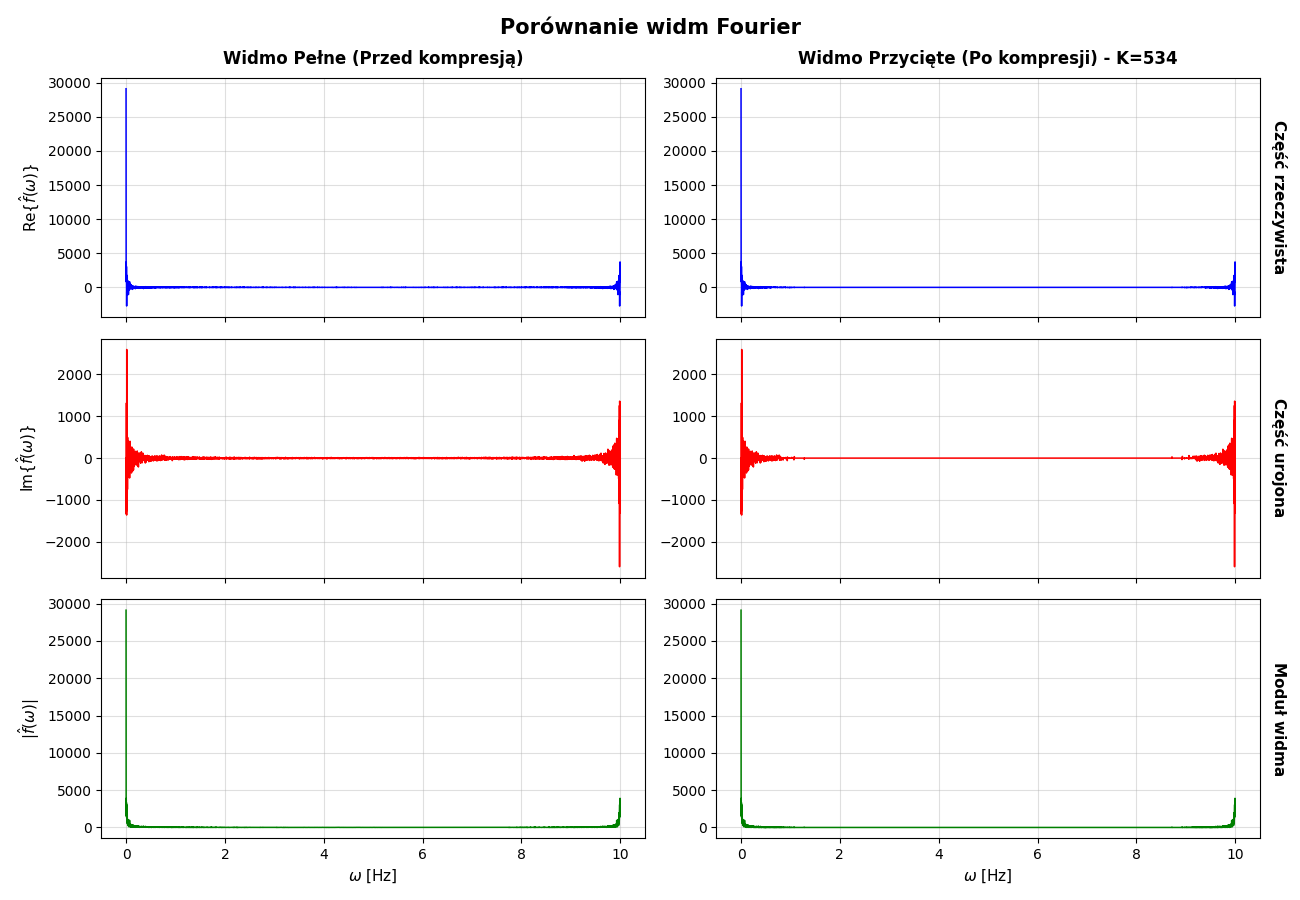

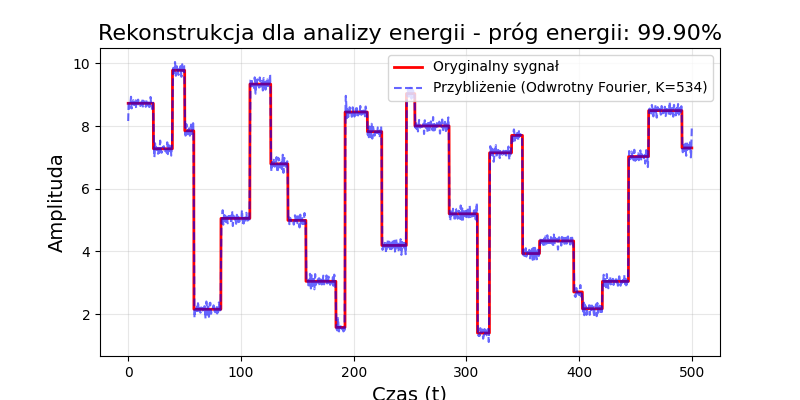

In [1]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Fourier import DiscreteFourier
from EnergyAnalyzer import EnergyAnalyzer
from Plotter import Plotter
from tabulate import tabulate
from TableRenderer import ReportTableRenderer
from SignalMetrics import SignalMetrics  

# Inicjalizacja generatora i utworzenie zbioru danych
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.1, seed=42)
dataset = creator.create_dataset(n_aprbs=1, n_multisine=1, n_noise=1)

# Wybór sygnału do analizy (można wybrać: 'aprbs', 'multisine', 'noise')
signal_type = 'aprbs'
signal = dataset[f'{signal_type}'][0]

# ----------------------------------------------------------------------------------
# 1. Wyznaczenie widma autorską metodą
omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

# 2. Analiza rozkładu energii (próg 99.9%)
energy_threshold = 0.999
results_dsc = EnergyAnalyzer.analyze_energy_distribution(f_omega_vec, N=len(signal.y), threshold=energy_threshold)

# 3. Kompresja - zerowanie nieistotnych składowych i rekonstrukcja sygnału
f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=results_dsc['k_threshold'])
y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)
# ----------------------------------------------------------------------------------

# Automatyczne wyliczenie pełnego zestawu metryk wierności i energii
metrics_results = SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed)

# Tabela raportująca – budowa identyczna jak w analizie Fidelity
headers = ["Parametr / Wskaźnik jakości", "Wartość"]

# Sekcja 1: Założenia eksperymentu i wynik selekcji progu energetycznego
rows = [
    ["[Konfiguracja] Tryb analizy błędu", "Dystrybucja Energii (Widmo)"],
    ["[Konfiguracja] Zadany próg energii", f"{energy_threshold * 100:.2f}%"],
    ["[Wynik selekcji] Wymagana liczba składowych (K)", f"{results_dsc['k_threshold']}"],
    ["Energia oryginału (w dziedzinie częstotliwości)", f"{results_dsc['total_energy_freq']:.4f}"],
]

# Sekcja 2: Automatyczne dołączenie wszystkich metryk ze słownika
for key, val in metrics_results.items():
    formatted_val = f"{val:.4f}%" if "strata" in key.lower() else (f"{val:.4f}" if isinstance(val, float) else str(val))
    rows.append([key, formatted_val])

# Wyświetlenie zintegrowanej tabeli
ReportTableRenderer.render(
    title=f"Kompletny raport wierności i energii sygnału {signal_type.upper()} (K = {results_dsc['k_threshold']})",
    headers=headers,
    rows=rows
)

# Wizualizacja porównania widm i rekonstrukcji
Plotter.plot_fourier_comparison_widma(omega_vec, f_omega_vec, f_trimmed, K=results_dsc['k_threshold'], title="Porównanie widm Fourier")
Plotter.plot_fourier_comparison(signal.t, signal.y, y_reconstructed, K=results_dsc['k_threshold'], title=f"Rekonstrukcja dla analizy energii - próg energii: {energy_threshold*100:.2f}%")

### 4.3 Algorytm oparty na analizie dokładności (MSE / Max Error): 


Alternatywnym podejściem do kompresji spektralnej jest algorytm adaptacyjny sterowany kryterium wierności odwzorowania sygnału w dziedzinie czasu (ang. *Fidelity Criteria*). W przeciwieństwie do metody energetycznej, która analizuje strukturę widma w sposób globalny i statyczny, podejście wiernościowe bezpośrednio minimalizuje błędy powstałe w wyniku obcięcia bazy ortogonalnej, monitorując jakość rekonstrukcji w sposób iteracyjny.

#### 4.3.1 Podstawa matematyczna i kryteria błędu

Algorytm realizuje proces optymalizacji poszukujący minimalnej liczby składowych częstotliwościowych $K$, dla których błąd odwzorowania sygnału nie przekracza zadanego progu tolerancji $\epsilon$. W zależności od założeń aplikacyjnych, w strukturze klasy `FidelityAnalyzer` zaimplementowano dwa alternatywne tryby pracy (wskaźniki jakości):

1. **Błąd średniokwadratowy (MSE):** Kryterium to określa średnią energię błędu w całym horyzoncie czasowym. Pozwala na optymalizację globalnego kształtu sygnału, dopuszczając lokalne, szpilkowe odchyłki:
$$\text{MSE} = \frac{1}{N} \sum_{n=0}^{N-1} \left( y[n] - \hat{y}[n] \right)^2 \le \epsilon$$

2. **Błąd maksymalny ($\text{Max Error}$):** Kryterium o charakterze reżimowym, które bezwzględnie limituje największą chwilową odchyłkę amplitudy. Jest kluczowe w układach, gdzie lokalne zniekształcenie sygnału (np. ucięcie wartości szczytowej) mogłoby zafałszować interpretację fizyczną danych:
$$\text{Max Error} = \max_{0 \le n < N} |y[n] - \hat{y}[n]| \le \epsilon$$

Gdzie $y[n]$ oznacza sygnał oryginalny o długości $N$ próbek, natomiast $\hat{y}[n]$ to sygnał testowy, rekonstruowany dynamicznie na podstawie $k$ dominujących prążków widmowych.

#### 4.3.2. Przebieg procedury kompresji

Klasyczna, zachłanna implementacja tego podejścia wiąże się z drastycznym wzrostem złożoności obliczeniowej. Wyznaczenie błędu w dziedzinie czasu wymaga wykonania odwrotnej dyskretnej transformaty Fouriera (IDFT) w każdym kroku pętli. Przy złożoności pojedynczej transformaty równej $\mathcal{O}(N^2)$ i przeszukiwaniu liniowym, całkowita teoretyczna złożoność algorytmu adaptacyjnego wynosiłaby $\mathcal{O}(N^3)$, co przy długości sygnału $N = 5000$ próbek prowadzi do wykonania miliardów operacji zmiennoprzecinkowych i paraliżu wydajnościowego środowiska wykonawczego.

W celu zachowania autonomii kodu (nieaktywna flaga `use_numpy=False`) przy jednoczesnym zapewnieniu wysokiej wydajności numerycznej, w metodzie `FidelityAnalyzer.analyze_by_error` zastosowano **optymalizację poprzez prekalkulację bazy transformacji** oraz **logarytmiczne wyszukiwanie binarne**. 

W strukturze skryptu testowego wydzielono trzy główne etapy przetwarzania:

1. **Wyznaczenie widma pełnego metodą statyczną:** W pierwszym kroku za pomocą statycznej metody `DiscreteFourier.transform()` przetwarzane są wektory czasu (`signal.t`) oraz wartości sygnału (`signal.y`). Wynikiem działania funkcji są dwa wektory: `omega_vec` (fizyczne częstotliwości w Hz) oraz `f_omega_vec` (pełne, obustronne widmo zespolone o długości równej liczbie próbek wejściowych $N$). Wektor ten stanowi bazę wejściową dla analizatora wierności.

2. **Iteracyjna analiza wierności (Klasa `FidelityAnalyzer`):** Wyznaczony wektor współczynników o długości $N$ oraz sygnał źródłowy przekazywane są do metody statycznej `FidelityAnalyzer.analyze_by_error()`. Wewnętrzna struktura tej metody realizuje zoptymalizowaną pętlę wyszukiwania binarnego (bisekcji), wykonując następujące kroki funkcjonalne:
   * **2.1. Sortowanie spektralne współczynników:** Algorytm oblicza moduły wszystkich zespolonych współczynników (`np.abs(coeffs)`) i porządkuje je malejąco za pomocą funkcji `np.argsort()[::-1]`. Wynikiem działania jest wektor indeksów `sorted_indices`, wskazujący składowe widma od najsilniejszej do najsłabszej.

   * **2.2. Prekalkulacja macierzy bazowej IDFT:** Przed uruchomieniem właściwej pętli program jednorazowo generuje kompletną macierz wykładników zespolonych dla odwrotnej transformaty (IDFT) o wymiarach $N \times N$. Macierz ta jest od razu skalowana przez współczynnik $1/N$ i transponowana do postaci `W_inv_T`. Wyciągnięcie tej ciężkiej alokacji przed pętlę chroni procesor przed ciągłym narzutem pamięciowym.

   * **2.3. Inicjalizacja wskaźników bisekcji:** Program definiuje początkowe punkty skrajne przedziału poszukiwań w dziedzinie częstotliwości (`low = 1`, `high = N`). Wykorzystanie bisekcji pozwala na drastyczne zredukowanie teoretycznej liczby kroków pętli ze złożoności liniowej $\mathcal{O}(N)$ do logarytmicznej $\mathcal{O}(\log_2 N)$. Przy głębokiej kompresji i rygorystycznych progach błędu (np. $\epsilon = 0.01$), zapobiega to wielokrotnemu powtarzaniu operacji macierzowych.

   * **2.4. Dynamiczne przycinanie i rekonstrukcja sygnału:** W każdej iteracji wyznaczany jest punkt środkowy przedziału `mid = (low + high) // 2`. Program tworzy maskę `test_coeffs` o długości $N$, aktywując wyłącznie `mid` dominujących prążków i zerując resztę pasma częstotliwościowego. Następnie synteza sygnału w czasie (`y_hat`) realizowana jest poprzez szybki iloczyn macierzowy `np.dot(W_inv_T, test_coeffs).real`, co pozwala optymalnie wykorzystać sprzętowe właściwości pamięci podręcznej procesora.

   * **2.5. Weryfikacja warunku stopu bisekcji:** W zależności od wybranego trybu (`mode='mse'` lub `mode='max_error'`), obliczany jest aktualny błąd odwzorowania sygnału `y_hat` względem `original_y`. Jeśli warunek dokładności jest spełniony (`current_error <= threshold`), algorytm tymczasowo zatrzaskuje zmienne wynikowe (`k_min = mid`, `reconstructed_y = y_hat`), po czym zawęża obszar poszukiwań do lewej połówki (`high = mid - 1`), sprawdzając, czy mniejsza liczba składowych również spełni kryterium. W przeciwnym wypadku, algorytm przenosi okno poszukiwań do prawej połówki (`low = mid + 1`). Pętla kończy pracę po zbiegnięciu się wskaźników, zwracając precyzyjnie wyznaczony próg kompresji.

3. **Kompresja (Przycięcie widma) i rekonstrukcja sygnału:** W ostatniej fazie wyznaczona adaptacyjnie wartość `results['k_threshold']` przekazywana jest wraz z bazowym widmem do metody statycznej `DiscreteFourier.trim_spectrum()`. Funkcja ta wyznacza próg amplitudy dla $K$-tego największego współczynnika, a następnie tworzy maskę logiczną, która zachowuje nienaruszone prążki dominujące, a wszystkie pozostałe składowe o niskiej istotności (szum, fluktuacje) nadpisuje wartością zero. Skompresowany w ten sposób wektor częstotliwości (`f_trimmed`) trafia do metody `DiscreteFourier.inverse_transform()`, gdzie za pomocą algorytmu IDFT następuje ostateczna synteza czysto rzeczywistego sygnału wyjściowego `y_reconstructed`.

Zastosowanie algorytmu przeszukiwania binarnego pozwoliło na redukcję teoretycznej złożonowści procedury adaptacyjnej z poziomu $\mathcal{O}(N^3)$ do klasy $\mathcal{O}(N^2 \log N)$. W połączeniu z niskopoziomową optymalizacją operacji BLAS, redukcja liczby niezbędnych operacji zmiennoprzecinkowych przełożyła się na radykalne skrócenie czasu obliczeń w testach empirycznych.


#### 4.3.3 Kod

Generowanie APRBS        :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]

Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Średniokwadratowy (MSE)
[Konfiguracja] Zadany próg tolerancji,0.0100
[Wynik selekcji] Wymagana liczba składowych (K),931
Energia oryginału (w dziedzinie czasu),214293.1608
Energia po rekonstrukcji (w dziedzinie czasu),214243.1853
Procentowa strata energii,0.0233%
MSE,0.0100
RMSE,0.1000
MAX ERROR,1.1680
Wskaźnik zniekształcenia PRD,1.53%


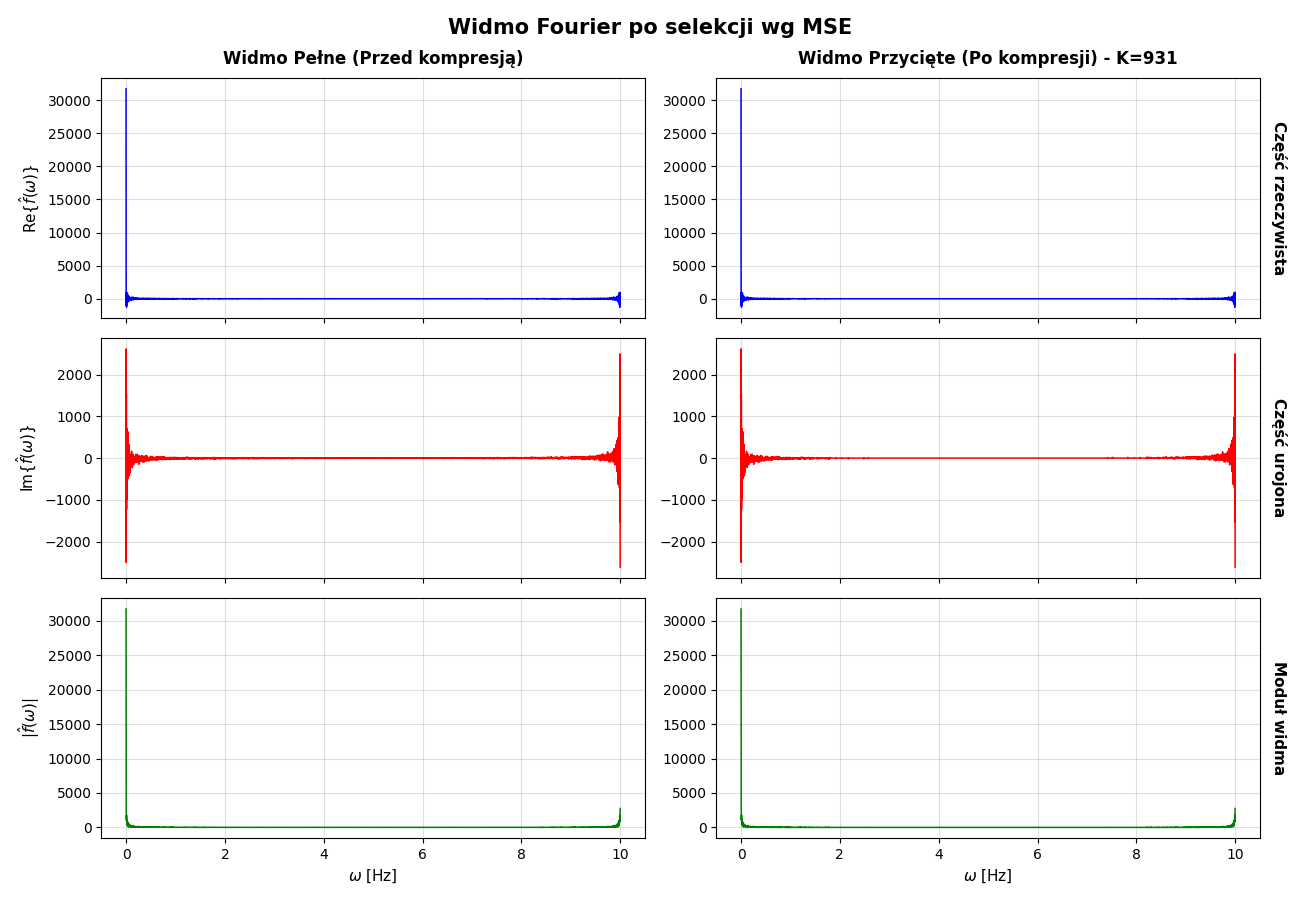

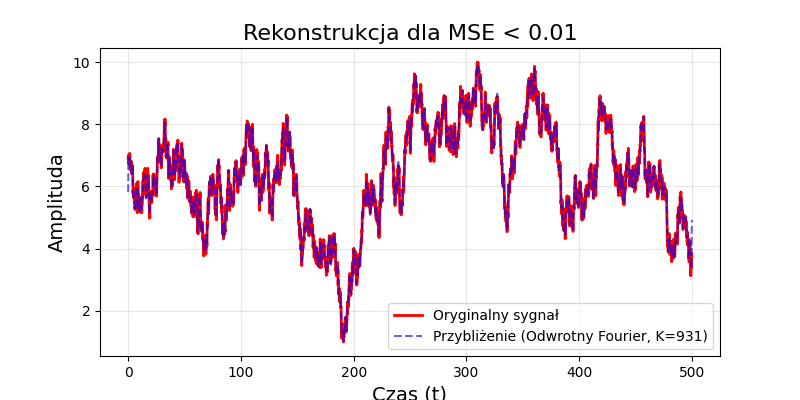

In [2]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import DiscreteFourier
from FidelityAnalyzer import FidelityAnalyzer
from TableRenderer import ReportTableRenderer 
from SignalMetrics import SignalMetrics

# Inicjalizacja generatora i utworzenie zbioru danych
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
dataset = creator.create_dataset(n_aprbs=1, n_multisine=1, n_noise=1)

# Wybór sygnału do analizy (można wybrać: 'aprbs', 'multisine', 'noise')
signal_type = 'noise'
signal = dataset[f'{signal_type}'][0]

# Konfiguracja kryterium wierności (Fidelity)
max_allowed_diff = 0.01 
mode = 'mse'  # Opcje: 'mse' lub 'max_error'

# ----------------------------------------------------------------------------------
# 1. Wyznaczenie widma autorską metodą Fouriera
omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

# 2. Analiza wierności - wyznaczenie progu K na podstawie zadanej tolerancji błędu
results = FidelityAnalyzer.analyze_by_error(signal.y, f_omega_vec, threshold=max_allowed_diff, mode=mode, use_numpy=False)

# 3. Kompresja - zerowanie nieistotnych składowych i rekonstrukcja sygnału
f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=results['k_threshold'])
y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)
# ----------------------------------------------------------------------------------

# Metryki jakości rekonstrukcji sygnału
metrics_results = SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed)

# Tabela raportująca wyniki analizy wierności i metryki jakości rekonstrukcji
error_label = "Średniokwadratowy (MSE)" if mode == 'mse' else "Maksymalny (MAX ERROR)"
headers = ["Parametr / Wskaźnik jakości", "Wartość"]

# Sekcja 1: Założenia eksperymentu i wynik selekcji progu
rows = [
    ["[Konfiguracja] Tryb analizy błędu", f"{error_label}"],
    ["[Konfiguracja] Zadany próg tolerancji", f"{max_allowed_diff:.4f}"],
    ["[Wynik selekcji] Wymagana liczba składowych (K)", f"{results['k_threshold']}"],
]

# Sekcja 2: Automatyczne dołączenie wszystkich metryk ze słownika
for key, val in metrics_results.items():
    formatted_val = f"{val:.4f}%" if "strata" in key.lower() else (f"{val:.4f}" if isinstance(val, float) else str(val))
    rows.append([key, formatted_val])

ReportTableRenderer.render(
    title=f"Kompletny raport wierności i energii sygnału {signal_type.upper()} (K = {results['k_threshold']})",
    headers=headers,
    rows=rows
)

# Wizualizacja porównania widm i rekonstrukcji
Plotter.plot_fourier_comparison_widma(omega_vec, f_omega_vec, f_trimmed, K=results['k_threshold'], title=f"Widmo Fourier po selekcji wg {mode.upper()}")
Plotter.plot_fourier_comparison(signal.t, signal.y, y_reconstructed, K=results['k_threshold'],title=f"Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}")

---

## 5. Testy



### 5.1 Założenia testowe

Definicja środowiska: jakie zestawy danych badasz (czysty vs zaszumiony stworzony z kopii), jakie progi energii (np. $90\%, 95\%, 99\%$) i błędu (np. $MSE < 0.01$) przyjmujesz do testów masowych.



### 5.3 Testy ilościowe algorytmów kompresji (Analiza Energii vs Analiza Dokładności)

#### 5.3.1. Efektywność kompresji dla sygnałów APRBS:

(Jak gwałtowne skoki wpływają na liczbę wymaganych współczynników w obu podejściach i jak przejawia się efekt Gibbsa).

#### 5.3.2. Efektywność kompresji dla sygnałów Multisine: 

(Pokazanie, że oba algorytmy idealnie wycinają zbędne tło i zostawiają tylko dominujące prążki).

#### 5.3.3. Efektywność kompresji dla przefiltrowanego szumu:

(Analiza zachowania filtracji przy rozproszonym widmie).


 
#### kod


Generowanie APRBS        :   0%|          | 0/5 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/5 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/5 [00:00<?, ?it/s]

Przetwarzanie kategorii: APRBS...
aprbs, 0
aprbs, 1
aprbs, 2
aprbs, 3
aprbs, 4
Przetwarzanie kategorii: MULTISINE...
multisine, 0
multisine, 1
multisine, 2
multisine, 3
multisine, 4
Przetwarzanie kategorii: NOISE...
noise, 0
noise, 1
noise, 2
noise, 3
noise, 4
Analiza zakończona.

--- RAPORT KOSZTU REPREZENTACJI (K) ---


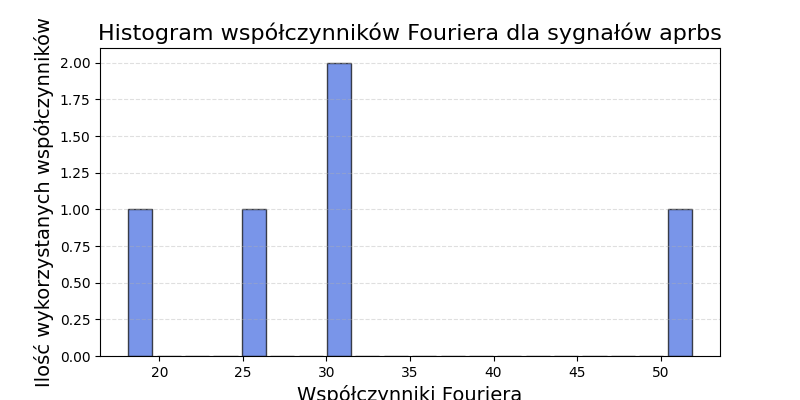

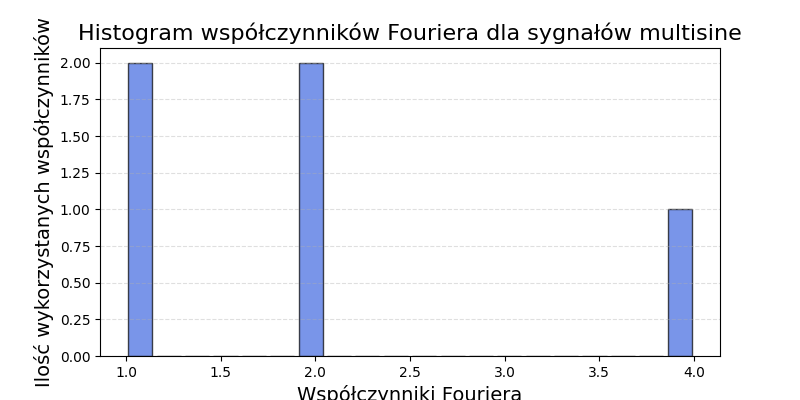

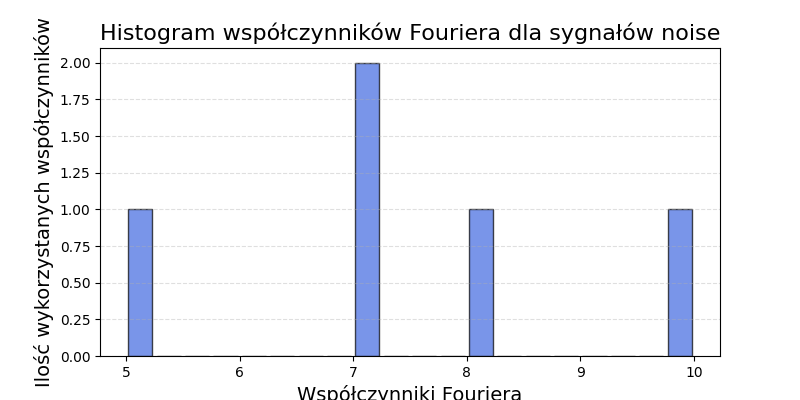

            category mean_k     std_k min_k max_k count
aprbs          aprbs   31.0   11.3842    18    52     5
multisine  multisine    2.0  1.095445     1     4     5
noise          noise    7.4  1.624808     5    10     5


In [4]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=5, n_multisine=5, n_noise=5)

tester = FidelityTester(big_dataset)

# Testy z naszą transformatą są długie (około 10 min)
stats = tester.run(threshold=1.0, mode='mse', use_custom_fft=True)

print("--- RAPORT KOSZTU REPREZENTACJI (K) ---")
print(tester.display_results())


### 5.5 Analiza wyników
parametry generatorów
zapisane wykresy i tabele
analiza

---

## 5. Kompresja Audio

co to wav

zastosowanie

własny koder i dekoder

kod do uruchomienia

wykresy i tabele

Analiza

---

## 6. Podsumowanie